# iDSTFT

In [13]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(device, torch.__version__)
torch.manual_seed(1802)

%load_ext autoreload
%autoreload 2
%matplotlib inline

cuda 2.9.1+cu128
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Signal and Loss Function Setup

In [14]:
def entropy_loss(x: torch.Tensor):
    """A simple loss function to encourage spectrogram sparsity."""
    x1 = torch.reshape(x, (x.shape[0], -1))  # B, N
    probs = torch.div(x1.T, x1.sum(dim=-1)).T  # B, N
    entropy = -(
        probs * torch.clamp(torch.log(probs), min=torch.finfo(x.dtype).min)
    ).sum(dim=-1)  # B
    return entropy.mean()

In [15]:
from math import pi


# Generate a complex signal with multiple components (original example)
duration = 1024
sr = 5
t = torch.arange(0, duration, 1 / sr, dtype=dtype, device=device) / float(duration)

phi1 = (300.0 * t + 60.0 * t**2) * sr
phi2 = (50.0 * t - 50.0 * t**2 + 50.0 * t**5) * sr

# component 1
comp1 = torch.cos(2 * torch.pi * phi1)

# component 2
comp2 = torch.cos(2 * torch.pi * phi2)

# component 3
exp_term = torch.exp(-2.0 * (t - 0.2))
sin_term = torch.sin(12.0 * pi * (t - 0.2))
phi3 = (300.0 * t - 3 * exp_term * sin_term) * sr
comp3 = torch.cos(2 * torch.pi * phi3)

x = (comp2 + comp3).real[None, :]  # shape (1, N)
x += 0.01 * torch.randn_like(x)  # add noise

print(f"Signal shape: {x.shape}, {x.device}")

Signal shape: torch.Size([1, 5120]), cuda:0


## 2. Standard STFT (Fixed Parameters)

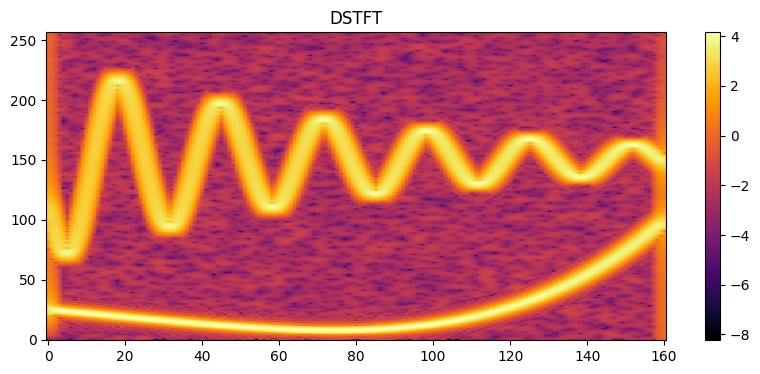

In [16]:
import matplotlib.pyplot as plt

from dstft import DSTFT


# Define analysis parameters
n_fft = 512
win_length = 256
hop_length = 32
epochs = 10_000
lr = 1
patience = 9
factor = 0.1
threshold = 0.5

dstft_fixed = DSTFT(
    win_length=win_length, n_fft=n_fft, hop_length=hop_length, window_mode="fixed"
)
dstft_fixed.initialize(x)
spec_fixed, stft_fixed = dstft_fixed(x)
plt.figure(figsize=(10, 4))
plt.title("DSTFT")
plt.imshow(
    spec_fixed[0].detach().cpu().log(), aspect="auto", origin="lower", cmap="inferno"
)
plt.colorbar()
plt.show()

 error 1.1937500232761522e-07


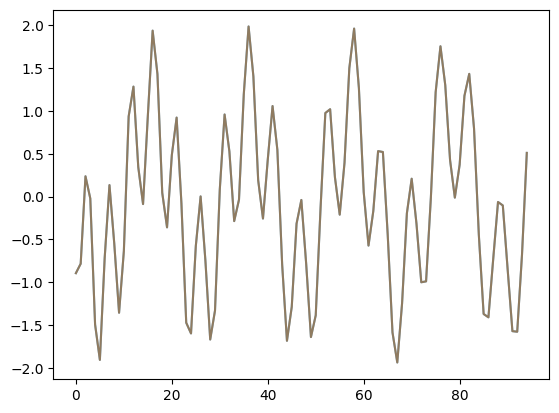

In [17]:
x_hat = dstft_fixed.inverse(stft_fixed)
plt.plot(x[0, 5:100].detach().cpu())
plt.plot(x_hat[0, 5:100].detach().cpu(), alpha=0.5)
print(" error", (x - x_hat).abs().mean().item())

## 3. Differentiable STFT (`DSTFT`)

### 3a. Learning a Single Global Window Length


Final learned win_length: 178.71983337402344


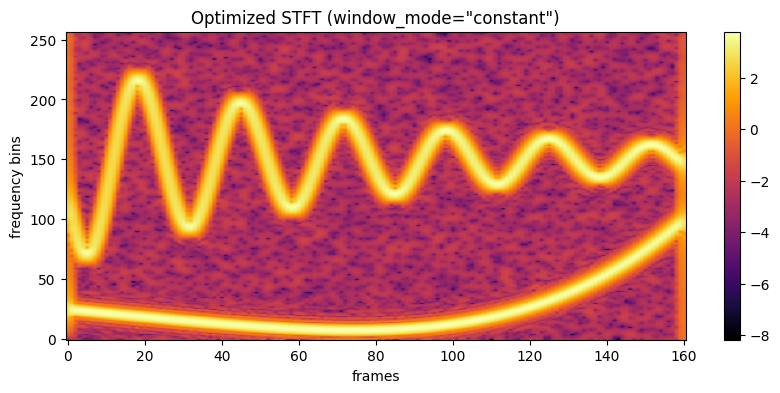

In [18]:
# 3a) Constant learnable window length (single scalar)
dstft_constant = DSTFT(
    win_length=win_length,
    n_fft=n_fft,
    hop_length=hop_length,
    window_mode="constant",
)

dstft_constant.initialize(x)
optimizer = torch.optim.Adam(dstft_constant.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=factor,
    patience=patience,
)

for _ in range(epochs):
    optimizer.zero_grad(set_to_none=True)
    spec, stft = dstft_constant(x)
    loss = entropy_loss(
        spec
    )  # geometric_sparsity(stft) snr_contrast(stft) entropy_loss(spec)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach())

    if optimizer.param_groups[0]["lr"] < threshold:
        break

print("\nFinal learned win_length:", dstft_constant.win_length.item())
spec_learn_constant, _ = dstft_constant(x)
dstft_constant.plot_spec(
    spec_learn_constant, title='Optimized STFT (window_mode="constant")', colorbar=True
);

 error 0.01765144243836403


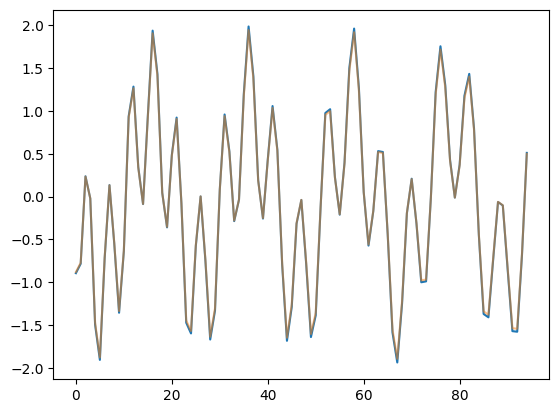

In [19]:
x_hat = dstft_constant.inverse(stft)
plt.plot(x[0, 5:100].detach().cpu())
plt.plot(x_hat[0, 5:100].detach().cpu(), alpha=0.5)
print(" error", (x - x_hat).abs().mean().item())

### 3b. Learning a Time-Varying Window Length

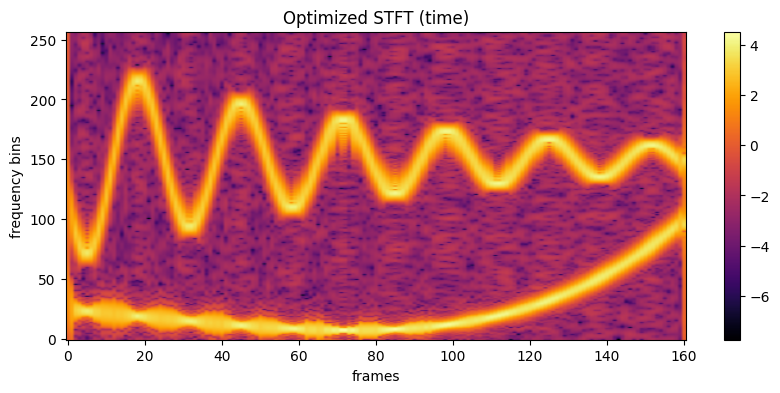

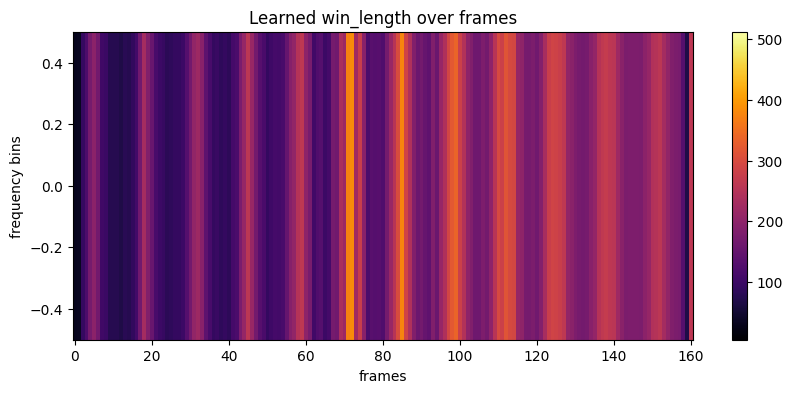

(<Figure size 1000x400 with 2 Axes>,
 <Axes: title={'center': 'Learned win_length over frames'}, xlabel='frames', ylabel='frequency bins'>)

In [20]:
# 3b) Time-varying learnable window length (one value per frame)
dstft_time = DSTFT(
    win_length=win_length,
    n_fft=n_fft,
    hop_length=hop_length,
    window_mode="time",
)
dstft_time.initialize(x)
optimizer = torch.optim.Adam(dstft_time.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=factor,
    patience=patience,
)

for _ in range(epochs):
    optimizer.zero_grad(set_to_none=True)
    spec, stft = dstft_time(x)
    loss = entropy_loss(spec)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach())

    if optimizer.param_groups[0]["lr"] < threshold:
        break

win_time = dstft_time.win_length.detach().cpu()
spec_learn_time, _ = dstft_time(x)
dstft_time.plot_spec(spec_learn_time, title='Optimized STFT (time)')
dstft_time.plot_win_lengths(title="Learned win_length over frames")

 error 0.005877796094864607


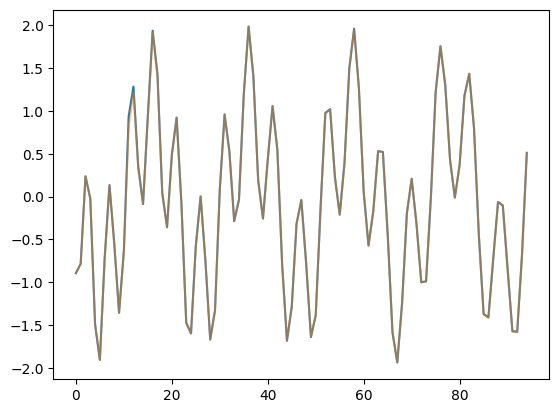

In [21]:
x_hat = dstft_time.inverse(stft)
plt.plot(x[0, 5:100].detach().cpu())
plt.plot(x_hat[0, 5:100].detach().cpu(), alpha=0.5)
print(" error", (x - x_hat).abs().mean().item())

## 4. Adaptive STFT (`ADSTFT`)

### 4a. Learning a Time-and-Frequency-Varying Window Length

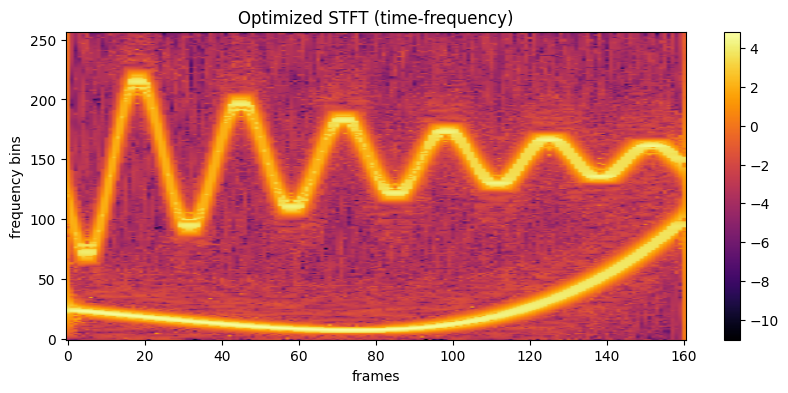

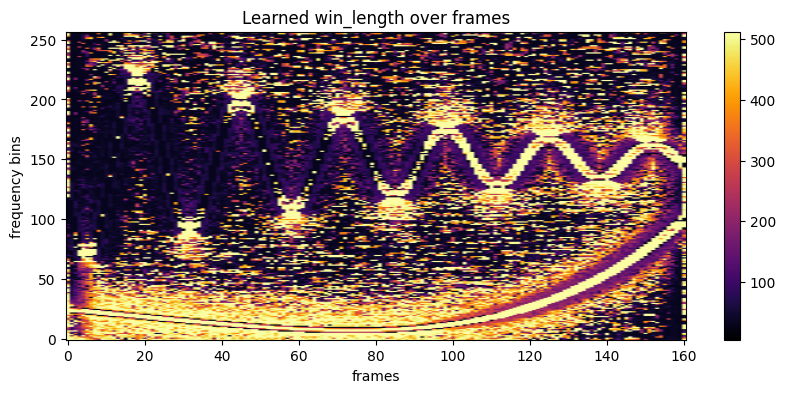

In [22]:
dstft_tf = DSTFT(
    win_length=win_length,
    n_fft=n_fft,
    hop_length=hop_length,
    window_mode="time-frequency",
)
dstft_tf.initialize(x)
optimizer = torch.optim.Adam(dstft_tf.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=factor,
    patience=patience,
)

for epoch in range(epochs):
    optimizer.zero_grad(set_to_none=True)
    spec, stft = dstft_tf(x)
    loss = entropy_loss(spec)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach())


    if optimizer.param_groups[0]["lr"] < threshold:
        break

win_time = dstft_tf.win_length.detach().cpu()
spec_learn_time, _ = dstft_tf(x)
dstft_tf.plot_spec(spec_learn_time, title='Optimized STFT (time-frequency)')
dstft_tf.plot_win_lengths(title="Learned win_length over frames");

 error 0.00531053775921464


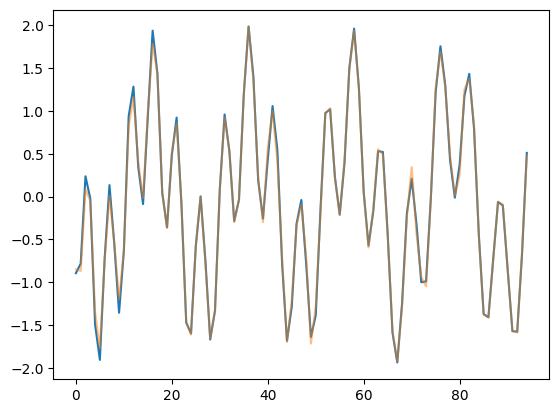

In [23]:
x_hat = dstft_tf.inverse(stft)
plt.plot(x[0, 5:100].detach().cpu())
plt.plot(x_hat[0, 5:100].detach().cpu(), alpha=0.5)
print(" error", (x - x_hat).abs().mean().item())